# Predictive Modelling - Linear Discriminant Analysis (LDA)

## Project Overview
This notebook builds a **Linear Discriminant Analysis (LDA)** classification model to predict customer churn using a cellphone customer dataset.

In [1]:
# Import required libraries
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

## 1. Load the Dataset

In [2]:
# Load dataset
# Keep this Excel file in the same folder as this notebook.
DATA_FILE = "Cellphone.xlsx"

if not os.path.exists(DATA_FILE):
    # Fallback path for notebook execution environments
    DATA_FILE = "/mnt/data/Cellphone.xlsx"

cell_df = pd.read_excel(DATA_FILE)

print("Dataset loaded successfully")
print("Shape:", cell_df.shape)
cell_df.head()

Dataset loaded successfully
Shape: (3333, 11)


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,1,108.0,0.0,0.0,0.38,2.0,115.1,114.0,41.8,10.57,13.8
1,0,113.0,1.0,1.0,3.59,1.0,44.9,63.0,55.9,6.71,13.3
2,0,101.0,1.0,0.0,0.00,0.0,257.3,84.0,60.0,9.24,13.5
3,0,80.0,1.0,1.0,2.89,4.0,166.4,92.0,77.9,11.92,10.7
4,0,70.0,1.0,0.0,0.00,0.0,175.4,130.0,44.0,7.98,11.6


## 2. Basic Data Inspection

In [3]:
cell_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3303 non-null   float64
 2   ContractRenewal  3315 non-null   float64
 3   DataPlan         3324 non-null   float64
 4   DataUsage        3317 non-null   float64
 5   CustServCalls    3281 non-null   float64
 6   DayMins          3298 non-null   float64
 7   DayCalls         3322 non-null   float64
 8   MonthlyCharge    3320 non-null   float64
 9   OverageFee       3309 non-null   float64
 10  RoamMins         3326 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 286.6 KB


In [4]:
cell_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Churn,3333.0,0.144914,0.352067,0.0,0.00,0.00,0.000,1.00
AccountWeeks,3303.0,101.159552,39.879736,1.0,74.00,101.00,127.000,243.00
ContractRenewal,3315.0,0.902866,0.296185,0.0,1.00,1.00,1.000,1.00
DataPlan,3324.0,0.276474,0.447321,0.0,0.00,0.00,1.000,1.00
DataUsage,3317.0,0.814827,1.270329,0.0,0.00,0.00,1.780,5.40
CustServCalls,3281.0,1.563852,1.318590,0.0,1.00,1.00,2.000,9.00
DayMins,3298.0,179.863069,54.581440,0.0,143.70,179.60,216.700,350.80
DayCalls,3322.0,100.434377,20.079248,0.0,87.00,101.00,114.000,165.00
MonthlyCharge,3320.0,56.288735,16.438343,14.0,45.00,53.50,66.125,111.30
OverageFee,3309.0,10.048598,2.539063,0.0,8.33,10.07,11.770,18.19


In [5]:
# Check missing values
missing_values = cell_df.isnull().sum()
missing_values[missing_values > 0]

AccountWeeks       30
ContractRenewal    18
DataPlan            9
DataUsage          16
CustServCalls      52
DayMins            35
DayCalls           11
MonthlyCharge      13
OverageFee         24
RoamMins            7
dtype: int64

## 3. Data Cleaning

The dataset contains missing values in both binary/categorical columns and continuous numerical columns.

Treatment used:
- `ContractRenewal` and `DataPlan`: filled using mode
- Other numerical variables: filled using median
- Target variable `Churn`: converted to integer

In [6]:
df = cell_df.copy()

target_col = "Churn"
binary_cols = ["ContractRenewal", "DataPlan"]
numeric_cols = [col for col in df.columns if col not in binary_cols + [target_col]]

# Fill binary columns with mode
for col in binary_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric columns with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Ensure target is integer
df[target_col] = df[target_col].astype(int)

print("Total missing values after cleaning:", df.isnull().sum().sum())
df.head()

Total missing values after cleaning: 0


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,1,108.0,0.0,0.0,0.38,2.0,115.1,114.0,41.8,10.57,13.8
1,0,113.0,1.0,1.0,3.59,1.0,44.9,63.0,55.9,6.71,13.3
2,0,101.0,1.0,0.0,0.00,0.0,257.3,84.0,60.0,9.24,13.5
3,0,80.0,1.0,1.0,2.89,4.0,166.4,92.0,77.9,11.92,10.7
4,0,70.0,1.0,0.0,0.00,0.0,175.4,130.0,44.0,7.98,11.6


In [7]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 4. Target Variable Distribution

Churn
0    2850
1     483
Name: count, dtype: int64

Percentage distribution:
Churn
0    85.51
1    14.49
Name: proportion, dtype: float64


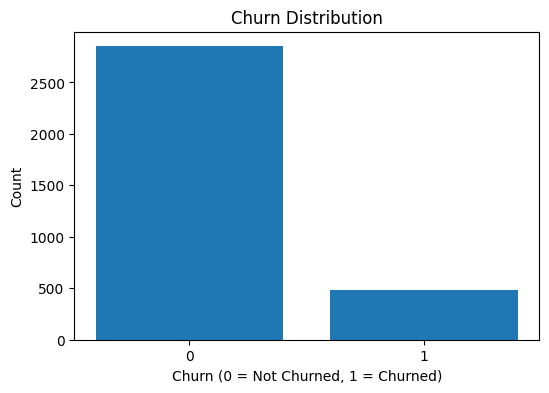

In [8]:
churn_counts = df["Churn"].value_counts().sort_index()
churn_percent = df["Churn"].value_counts(normalize=True).sort_index() * 100

print(churn_counts)
print("\nPercentage distribution:")
print(churn_percent.round(2))

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index.astype(str), churn_counts.values)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Not Churned, 1 = Churned)")
plt.ylabel("Count")
plt.show()

**Observation:**  
The dataset is imbalanced. Most customers belong to the non-churn class, while churn customers form a smaller group. Because of this, accuracy alone is not enough to judge the model. Recall, precision, F1-score, and ROC-AUC should also be checked.

## 5. Exploratory Data Analysis

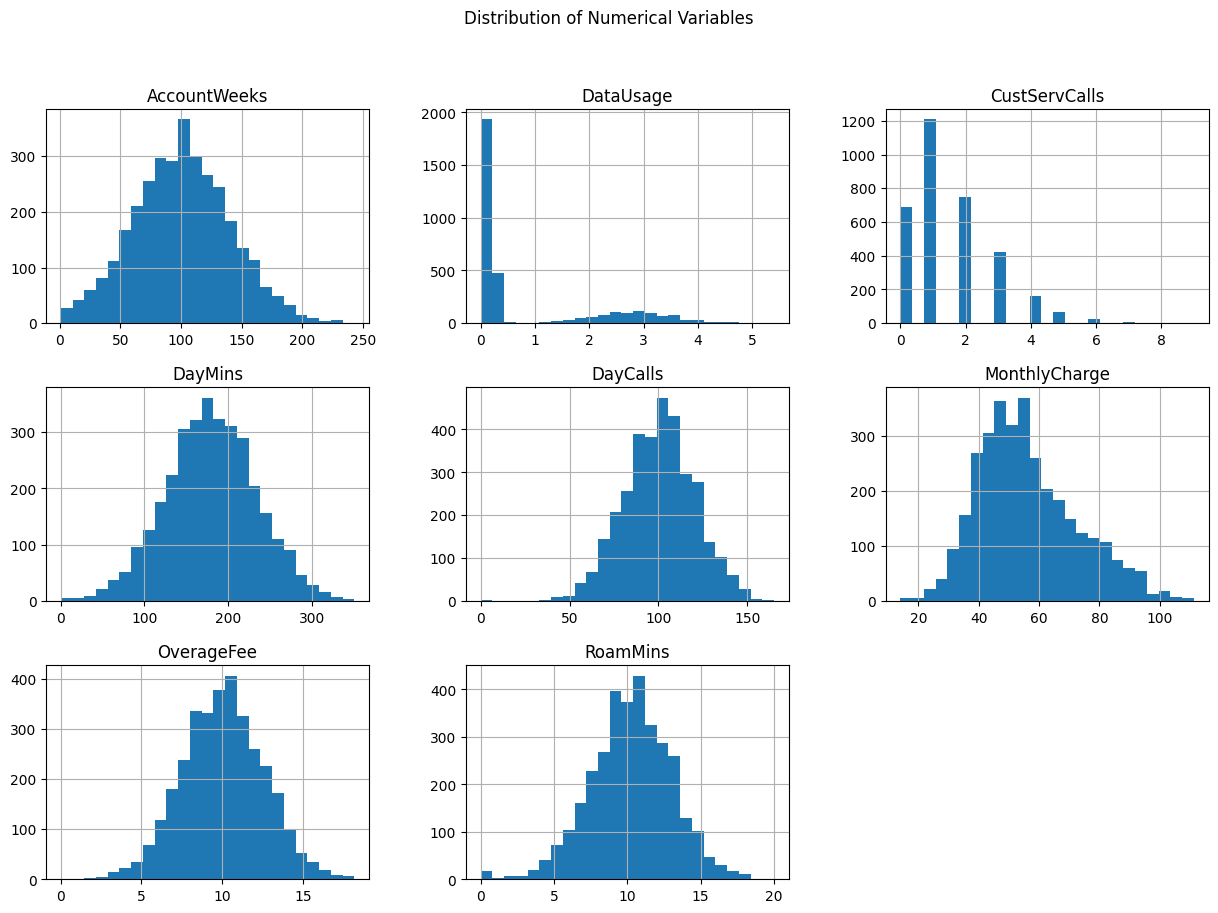

In [9]:
eda_cols = ["AccountWeeks", "DataUsage", "CustServCalls", "DayMins", 
            "DayCalls", "MonthlyCharge", "OverageFee", "RoamMins"]

df[eda_cols].hist(figsize=(15, 10), bins=25)
plt.suptitle("Distribution of Numerical Variables")
plt.show()

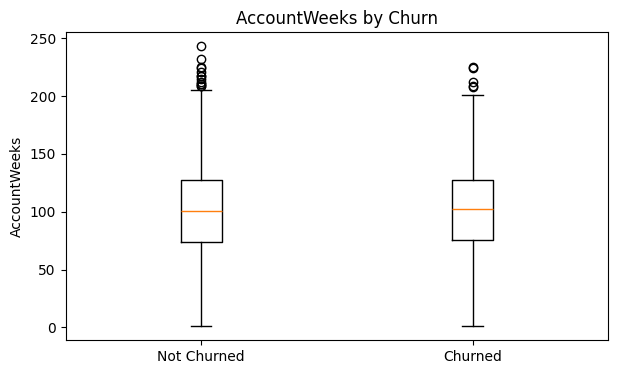

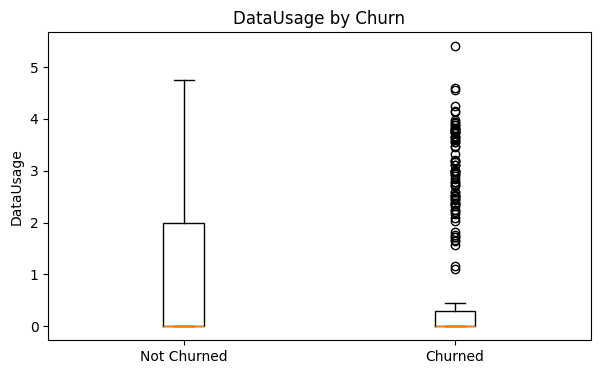

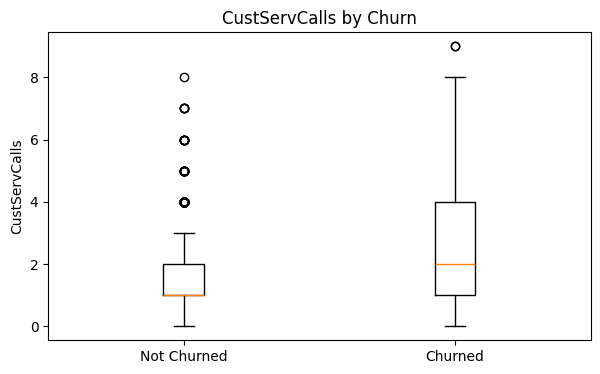

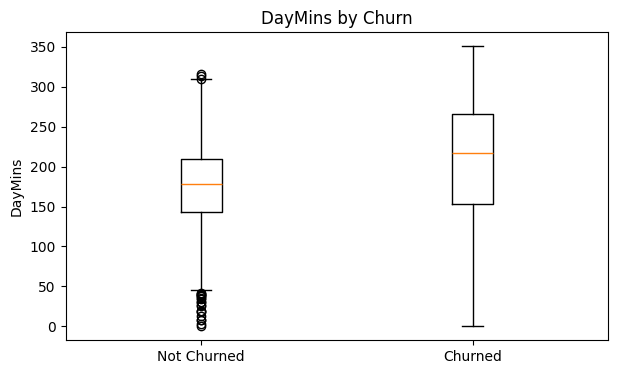

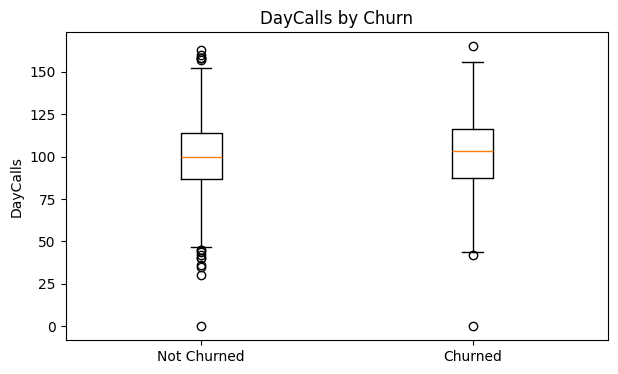

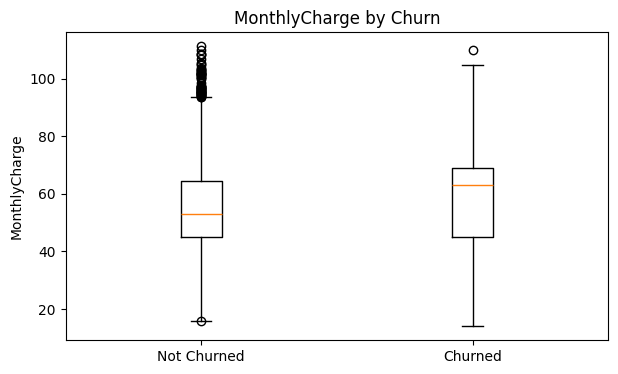

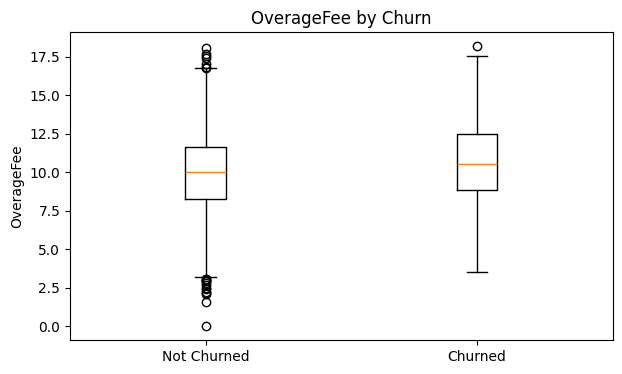

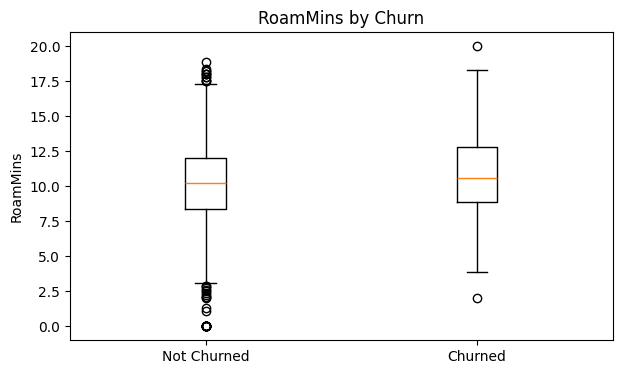

In [10]:
# Boxplots for numerical variables by churn class
for col in eda_cols:
    data_0 = df.loc[df["Churn"] == 0, col]
    data_1 = df.loc[df["Churn"] == 1, col]

    plt.figure(figsize=(7, 4))
    plt.boxplot([data_0, data_1], labels=["Not Churned", "Churned"])
    plt.title(f"{col} by Churn")
    plt.ylabel(col)
    plt.show()

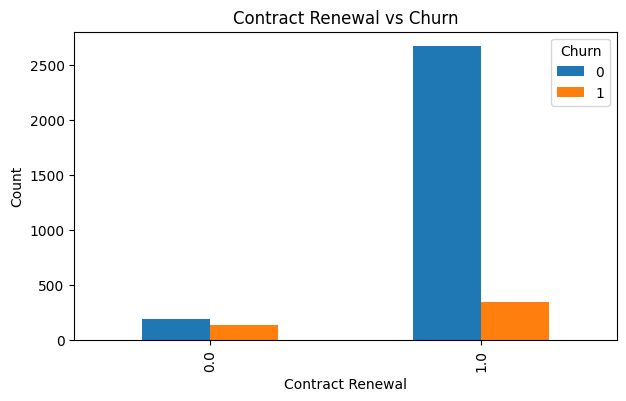

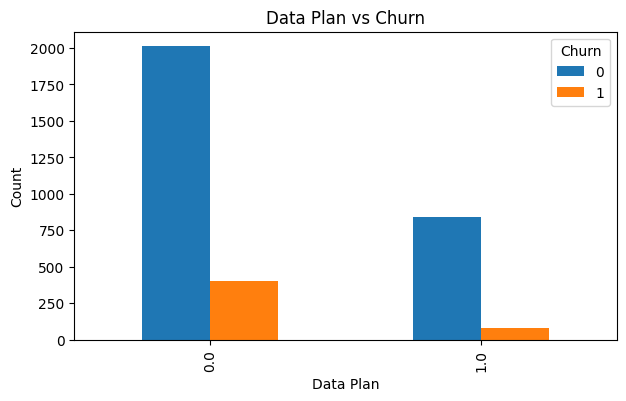

In [11]:
# Contract Renewal vs Churn
contract_table = pd.crosstab(df["ContractRenewal"], df["Churn"])
contract_table.plot(kind="bar", figsize=(7, 4))
plt.title("Contract Renewal vs Churn")
plt.xlabel("Contract Renewal")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

# Data Plan vs Churn
data_plan_table = pd.crosstab(df["DataPlan"], df["Churn"])
data_plan_table.plot(kind="bar", figsize=(7, 4))
plt.title("Data Plan vs Churn")
plt.xlabel("Data Plan")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

## 6. Train-Test Split

In [12]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2333, 10)
X_test shape: (1000, 10)
y_train shape: (2333,)
y_test shape: (1000,)


## 7. Feature Scaling

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Build Linear Discriminant Analysis Model

In [14]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)

y_train_pred = lda_model.predict(X_train_scaled)
y_test_pred = lda_model.predict(X_test_scaled)

y_train_prob = lda_model.predict_proba(X_train_scaled)[:, 1]
y_test_prob = lda_model.predict_proba(X_test_scaled)[:, 1]

## 9. Model Evaluation

In [15]:
print("Training Classification Report:\n")
print(metrics.classification_report(y_train, y_train_pred))

print("Test Classification Report:\n")
print(metrics.classification_report(y_test, y_test_pred))

Training Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.95      0.92      1995
           1       0.47      0.24      0.32       338

    accuracy                           0.85      2333
   macro avg       0.67      0.60      0.62      2333
weighted avg       0.82      0.85      0.83      2333

Test Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       855
           1       0.48      0.28      0.35       145

    accuracy                           0.85      1000
   macro avg       0.68      0.61      0.63      1000
weighted avg       0.83      0.85      0.83      1000



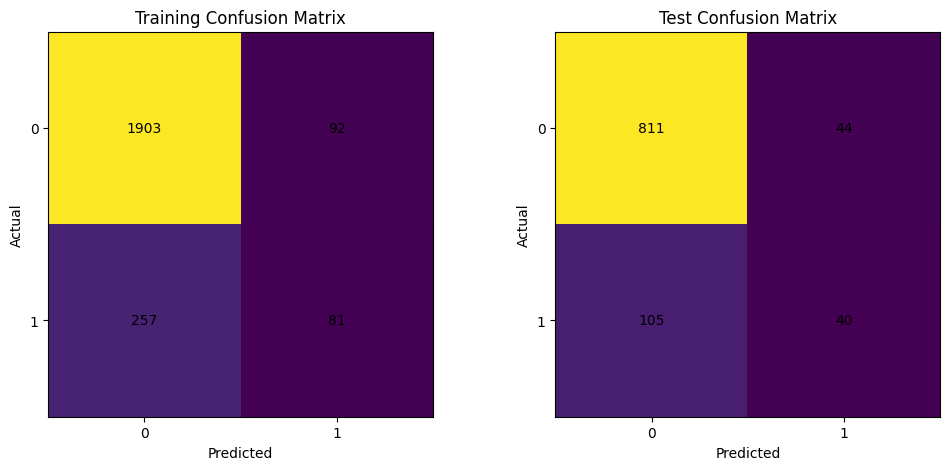

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train_cm = metrics.confusion_matrix(y_train, y_train_pred)
test_cm = metrics.confusion_matrix(y_test, y_test_pred)

for ax, cm, title in zip(axes, [train_cm, test_cm], ["Training Confusion Matrix", "Test Confusion Matrix"]):
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

Training ROC-AUC: 0.82
Test ROC-AUC: 0.829


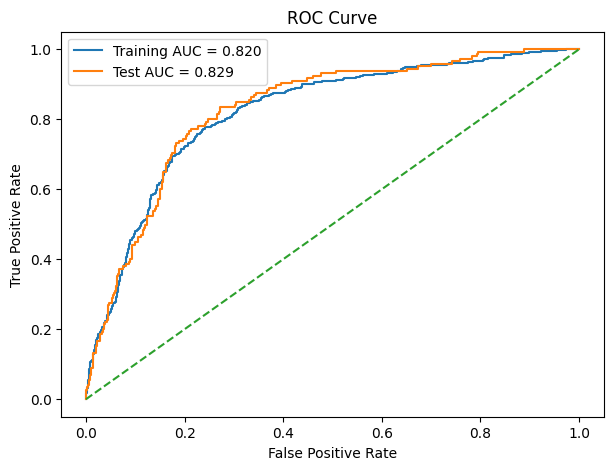

In [17]:
train_auc = metrics.roc_auc_score(y_train, y_train_prob)
test_auc = metrics.roc_auc_score(y_test, y_test_prob)

print("Training ROC-AUC:", round(train_auc, 3))
print("Test ROC-AUC:", round(test_auc, 3))

fpr_train, tpr_train, _ = metrics.roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = metrics.roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr_train, tpr_train, label=f"Training AUC = {train_auc:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 10. Feature Importance from LDA Coefficients

In [18]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "LDA_Coefficient": lda_model.coef_[0]
})

coef_df["Absolute_Impact"] = coef_df["LDA_Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute_Impact", ascending=False)

coef_df

,Feature,LDA_Coefficient,Absolute_Impact
1,ContractRenewal,-0.875581,0.875581
4,CustServCalls,0.765738,0.765738
5,DayMins,0.478068,0.478068
3,DataUsage,-0.310840,0.310840
2,DataPlan,-0.295251,0.295251
7,MonthlyCharge,0.293821,0.293821
8,OverageFee,0.239432,0.239432
9,RoamMins,0.180575,0.180575
6,DayCalls,0.048724,0.048724
0,AccountWeeks,-0.001603,0.001603


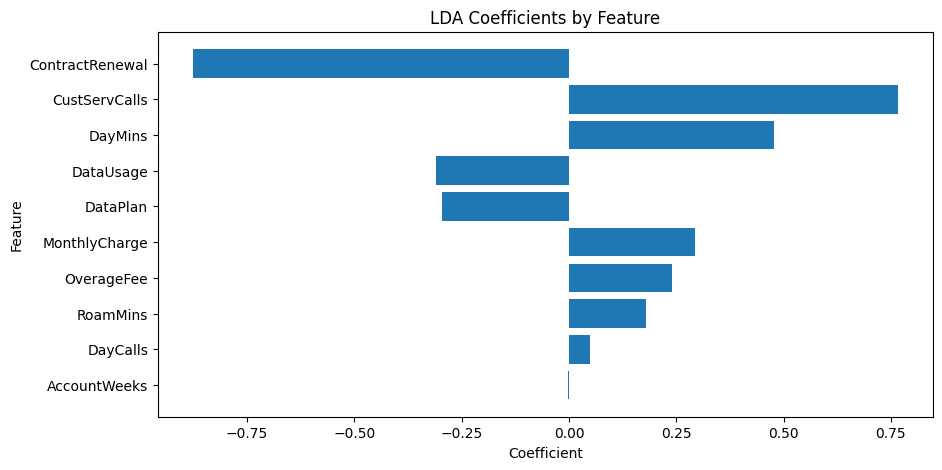

In [19]:
plt.figure(figsize=(10, 5))
plt.barh(coef_df["Feature"], coef_df["LDA_Coefficient"])
plt.title("LDA Coefficients by Feature")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

**Coefficient interpretation:**  
- Positive coefficients increase the likelihood of churn.
- Negative coefficients reduce the likelihood of churn.
- Larger absolute values indicate stronger influence on the LDA decision boundary.

## 11. Threshold Analysis

Best threshold based on F1-score: 0.175
Best F1-score: 0.52
Classification Report with Adjusted Threshold:

              precision    recall  f1-score   support

           0       0.95      0.82      0.88       855
           1       0.41      0.72      0.52       145

    accuracy                           0.81      1000
   macro avg       0.68      0.77      0.70      1000
weighted avg       0.87      0.81      0.83      1000



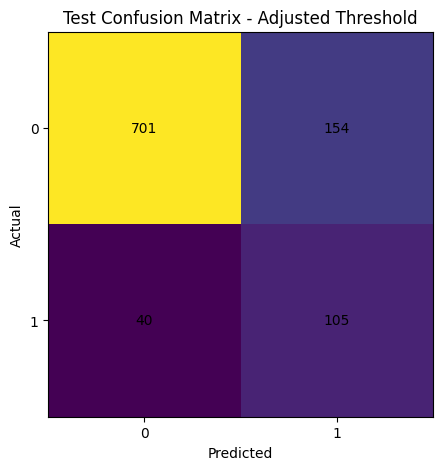

In [20]:
# Default prediction uses a 0.50 threshold.
# Since churn is imbalanced, we also check a threshold that improves F1-score for churn class.

precision, recall, thresholds = metrics.precision_recall_curve(y_test, y_test_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print("Best threshold based on F1-score:", round(best_threshold, 3))
print("Best F1-score:", round(f1_scores[best_idx], 3))

y_test_pred_adjusted = (y_test_prob >= best_threshold).astype(int)

print("Classification Report with Adjusted Threshold:\n")
print(metrics.classification_report(y_test, y_test_pred_adjusted))

cm = metrics.confusion_matrix(y_test, y_test_pred_adjusted)
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Test Confusion Matrix - Adjusted Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

## 12. LDA Dimensionality Reduction and Logistic Regression Comparison

In [21]:
# For binary classification, LDA can create only one discriminant component.
lda_transformer = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda_transformer.fit_transform(X_train_scaled, y_train)
X_test_lda = lda_transformer.transform(X_test_scaled)

print("X_train_lda shape:", X_train_lda.shape)
print("X_test_lda shape:", X_test_lda.shape)

log_model = LogisticRegression()
log_model.fit(X_train_lda, y_train)

log_pred = log_model.predict(X_test_lda)

print("Logistic Regression on LDA Component - Test Classification Report:\n")
print(metrics.classification_report(y_test, log_pred))

X_train_lda shape: (2333, 1)
X_test_lda shape: (1000, 1)
Logistic Regression on LDA Component - Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       855
           1       0.50      0.19      0.27       145

    accuracy                           0.85      1000
   macro avg       0.69      0.58      0.60      1000
weighted avg       0.82      0.85      0.83      1000



## Observations

1. The dataset contains **3,333 customer records** and **11 columns**.
2. The target variable is `Churn`, where:
   - `0` means the customer did not churn
   - `1` means the customer churned
3. The dataset is imbalanced because the number of non-churn customers is much higher than churn customers.
4. Missing values were present in multiple columns and were handled using mode or median imputation.
5. The LDA model achieved good overall accuracy, but churn recall is lower at the default threshold because churn customers are the minority class.
6. ROC-AUC is a better evaluation metric here than accuracy because the data is imbalanced.
7. Important churn-related variables include contract renewal, customer service calls, day minutes, data usage, monthly charge, and overage fee.
8. Adjusting the classification threshold improves churn recall, but it also increases false positives.
9. Logistic Regression on the single LDA component gives a comparable result, but the direct LDA model is easier to interpret for this classification task.

## Conclusion

The Linear Discriminant Analysis model successfully classifies cellphone customers into churn and non-churn categories using customer usage and service-related variables.

The model performs well in identifying non-churn customers, but due to class imbalance, it has lower recall for churn customers at the default threshold. For business use, the threshold can be adjusted to identify more potential churn customers, especially when the company wants to take preventive action through retention campaigns.

Overall, this project demonstrates how LDA can be used as a predictive modeling technique for customer churn analysis and how model evaluation should consider class imbalance, not just accuracy.